In [3]:
import os
import math
import time
import random
from typing import Tuple, Dict, List

import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

# Датасеты / трансформации
import torchvision
from torchvision import transforms

import os
import math
import time
import random
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


In [4]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Детеминизм (может замедлить)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

FAST_MODE = False   # переключите на True для частичного датасета и более быстрого обучения
DATA_DIR = "./data"

BATCH_SIZE = 128
EPOCHS = 4 if FAST_MODE else 12

Device: cpu


In [5]:
STL10_MEAN = (0.4467, 0.4398, 0.4067)
STL10_STD = (0.2242, 0.2215, 0.2239)

def load_stl10(data_dir: str = DATA_DIR, tf_train = None):

    tf_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD),
    ])

    ds_train_full = torchvision.datasets.STL10(root=data_dir, download=True, transform=tf_train)
    ds_test = torchvision.datasets.STL10(root=data_dir, download=True, transform=tf_test)

    return ds_train_full, ds_test



In [6]:
tf_train1 = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD),
    ])
ds_train_full1, ds_test1 = load_stl10(tf_train=tf_train1)
class_names = ds_train_full1.classes

print("Train full:", len(ds_train_full1))
print("Test:", len(ds_test1))
print("Classes:", class_names)

Train full: 5000
Test: 5000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [7]:
tf_train2 = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD),
    ])
ds_train_full2, ds_test2 = load_stl10(tf_train=tf_train2)
class_names = ds_train_full2.classes

print("Train full:", len(ds_train_full2))
print("Test:", len(ds_test2))
print("Classes:", class_names)

Train full: 5000
Test: 5000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [8]:
def make_loaders(
    ds_train_full,
    ds_test,
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    # train/val split
    n_total = len(ds_train_full)
    n_val = int(n_total * val_ratio)
    n_train = n_total - n_val

    ds_train, ds_val = random_split(
        ds_train_full,
        lengths=[n_train, n_val],
        generator=torch.Generator().manual_seed(seed),
    )

    # FAST_MODE: уменьшаем размер для скорости
    if fast_mode:
        # аккуратно: Subset от Subset (random_split возвращает Subset)
        rng = np.random.RandomState(seed)
        train_idx = rng.choice(len(ds_train), size=min(6000, len(ds_train)), replace=False)
        val_idx = rng.choice(len(ds_val), size=min(1500, len(ds_val)), replace=False)
        test_idx = rng.choice(len(ds_test), size=min(1500, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx)
        ds_val = Subset(ds_val, val_idx)
        ds_test_small = Subset(ds_test, test_idx)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(ds_train_full1, ds_test1)
batch = next(iter(train_loader))
x, y = batch
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)
train_loader2, val_loader2, test_loader2 = make_loaders(ds_train_full2, ds_test2)
batch = next(iter(train_loader2))
x2, y2 = batch
print("x:", x2.shape, x2.dtype)
print("y:", y2.shape, y2.dtype)

c:\Users\Пётр\Desktop\IAIapp\IAI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


x: torch.Size([128, 3, 96, 96]) torch.float32
y: torch.Size([128]) torch.int64
x: torch.Size([128, 3, 96, 96]) torch.float32
y: torch.Size([128]) torch.int64


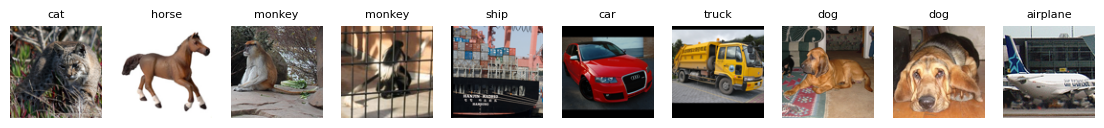

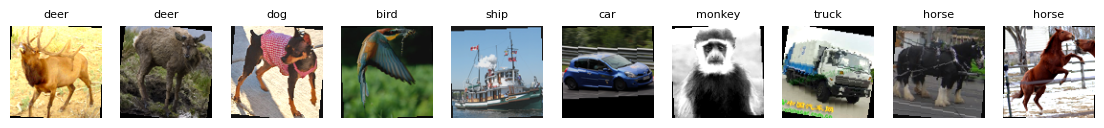

In [9]:
def denorm_cifar(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(STL10_MEAN).view(3, 1, 1)
    std = torch.tensor(STL10_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_cifar(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)
show_images(train_loader2, n=10)

In [10]:
NUM_CLASSES = 10


class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 32x32 -> 32x32
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 16x16 -> 16x16
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 8x8 -> 8x8
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 8x8 -> 4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x
    
    
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)



cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=18432, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Trainable params: 4814666


In [11]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()


Experiment CNN1_simple | lr=0.001 weight_decay=0.0 epochs=12
Trainable params: 4814666
Epoch 01/12 | train loss 1.9320, acc 0.289 | val loss 1.7677, acc 0.345 | 40.9s
Epoch 02/12 | train loss 1.5084, acc 0.442 | val loss 1.5510, acc 0.421 | 40.3s
Epoch 03/12 | train loss 1.3196, acc 0.516 | val loss 1.5187, acc 0.462 | 42.1s
Epoch 04/12 | train loss 1.1318, acc 0.588 | val loss 1.2868, acc 0.537 | 40.3s
Epoch 05/12 | train loss 0.9377, acc 0.670 | val loss 1.2891, acc 0.558 | 40.0s
Epoch 06/12 | train loss 0.7473, acc 0.731 | val loss 1.3066, acc 0.548 | 40.0s
Epoch 07/12 | train loss 0.5683, acc 0.804 | val loss 1.4077, acc 0.557 | 40.0s
Epoch 08/12 | train loss 0.3615, acc 0.887 | val loss 1.5318, acc 0.588 | 39.4s
Epoch 09/12 | train loss 0.2193, acc 0.936 | val loss 1.6828, acc 0.571 | 39.5s
Epoch 10/12 | train loss 0.1069, acc 0.974 | val loss 2.0033, acc 0.593 | 39.1s
Epoch 11/12 | train loss 0.0588, acc 0.990 | val loss 2.0707, acc 0.579 | 39.1s
Epoch 12/12 | train loss 0.0315,

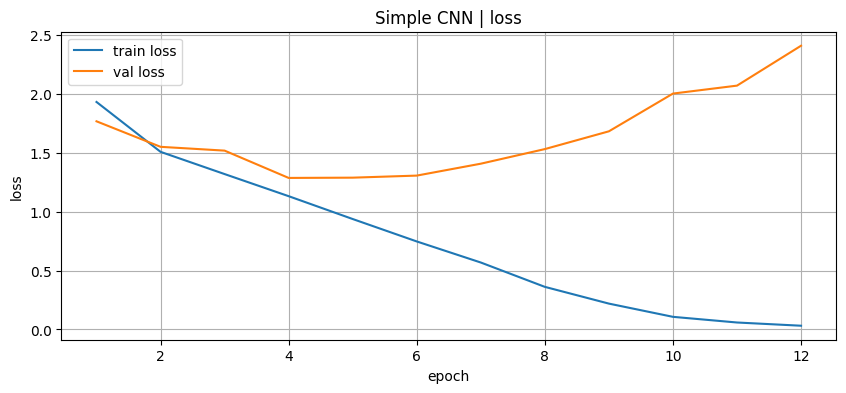

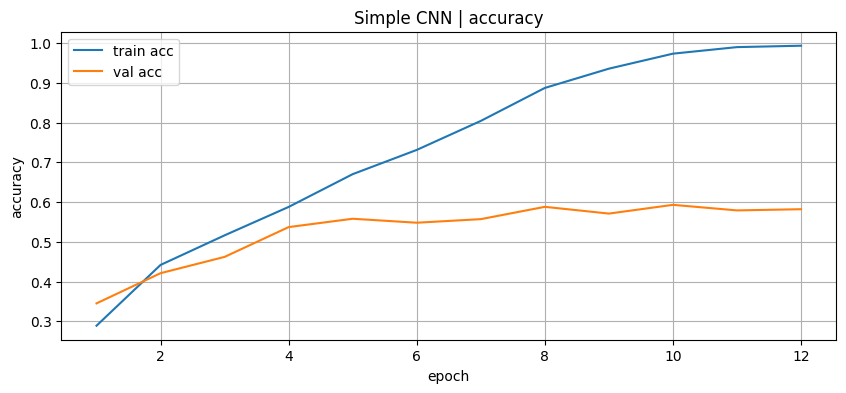

In [12]:
criterion = nn.CrossEntropyLoss()


exp_id = "CNN1_simple"
lr = 1e-3
weight_decay = 0.0
model = SimpleCNN(NUM_CLASSES)
epochs = EPOCHS
model = model.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.0)
print("\n" + "=" * 80)
print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
print("Trainable params:", count_params(model))
hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")
plot_history(hist, title="Simple CNN")


Experiment CNN2_simple | lr=0.001 weight_decay=0.0 epochs=12
Trainable params: 4814666
Epoch 01/12 | train loss 2.0916, acc 0.236 | val loss 1.8222, acc 0.332 | 39.6s
Epoch 02/12 | train loss 1.6585, acc 0.382 | val loss 1.6478, acc 0.387 | 40.1s
Epoch 03/12 | train loss 1.4526, acc 0.466 | val loss 1.4277, acc 0.466 | 39.0s
Epoch 04/12 | train loss 1.2914, acc 0.528 | val loss 1.3804, acc 0.487 | 39.1s
Epoch 05/12 | train loss 1.2061, acc 0.562 | val loss 1.2994, acc 0.524 | 39.7s
Epoch 06/12 | train loss 1.1203, acc 0.594 | val loss 1.2676, acc 0.546 | 39.5s
Epoch 07/12 | train loss 1.0535, acc 0.618 | val loss 1.2653, acc 0.541 | 39.5s
Epoch 08/12 | train loss 0.9713, acc 0.658 | val loss 1.2562, acc 0.541 | 39.5s
Epoch 09/12 | train loss 0.9177, acc 0.668 | val loss 1.2626, acc 0.533 | 39.3s
Epoch 10/12 | train loss 0.8401, acc 0.705 | val loss 1.1997, acc 0.581 | 39.6s
Epoch 11/12 | train loss 0.7727, acc 0.719 | val loss 1.2811, acc 0.582 | 39.4s
Epoch 12/12 | train loss 0.7190,

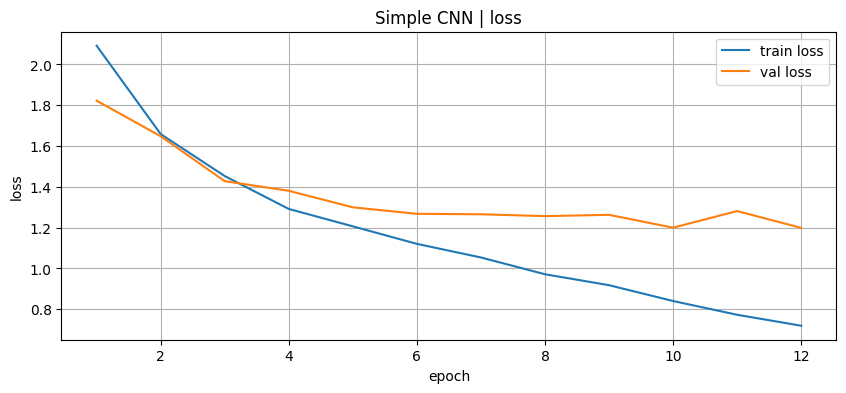

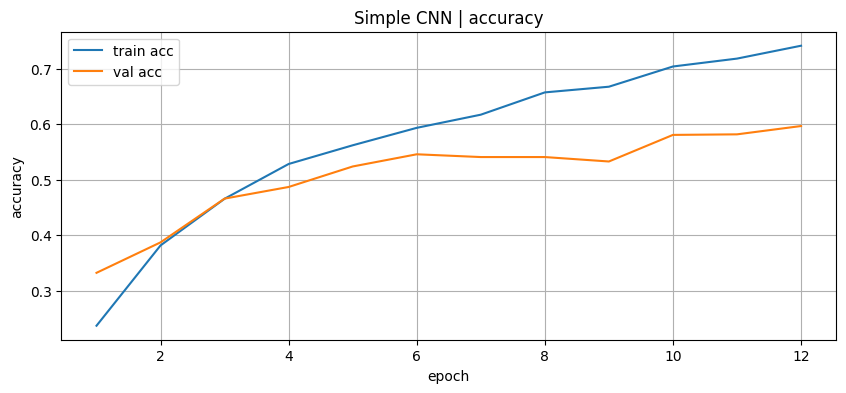

In [13]:
criterion = nn.CrossEntropyLoss()


exp_id = "CNN2_simple"
lr = 1e-3
weight_decay = 0.0
model = SimpleCNN(NUM_CLASSES)
epochs = EPOCHS
model = model.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.0)
print("\n" + "=" * 80)
print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
print("Trainable params:", count_params(model))
hist = fit(model, train_loader2, val_loader2, optimizer, criterion, epochs=epochs, verbose=True)
best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")
plot_history(hist, title="Simple CNN")

In [14]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

FAST_MODE = True
DATA_DIR = "./data"

BATCH_SIZE = 64  # ResNet тяжелее, чем SimpleCNN
EPOCHS_HEAD = 3 if FAST_MODE else 8
EPOCHS_FT   = 3 if FAST_MODE else 8
     

Device: cpu


In [15]:

def get_resnet18_weights():
    # Пытаемся взять предобученные веса. Если не получилось – вернем None.
    try:
        w = ResNet18_Weights.DEFAULT
        # иногда ошибка возникает не здесь, а при фактической загрузке весов;
        # но на практике этого достаточно как "правильный путь".
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)

weights: ResNet18_Weights.IMAGENET1K_V1


In [16]:
# mean/std для нормализации (если weights=None – используем стандартные ImageNet)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Для CIFAR-10 придётся изменить размер (ResNet обычно ожидает ~224x224).
# Чтобы было быстрее, можно выбрать размер 160 или 192. Оставим 224 как стандарт.
IMG_SIZE = 224

train_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def load_cifar10_tl(data_dir: str = DATA_DIR):
    # Важно: для train нужны аугментации, для val/test – детерминированные transforms.
    # Поэтому создаём ДВА варианта train-датасета с разными transforms и будем делить по одним и тем же индексам.
    ds_train_aug  = torchvision.datasets.CIFAR10(root=data_dir, train=True, download=True, transform=train_tf)
    ds_train_eval = torchvision.datasets.CIFAR10(root=data_dir, train=True, download=True, transform=eval_tf)
    ds_test       = torchvision.datasets.CIFAR10(root=data_dir, train=False, download=True, transform=eval_tf)
    return ds_train_aug, ds_train_eval, ds_test

ds_train_aug, ds_train_eval, ds_test = load_cifar10_tl()
class_names = ds_train_aug.classes
print("Train full:", len(ds_train_aug))
print("Test:", len(ds_test))

c:\Users\Пётр\Desktop\IAIapp\IAI\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train full: 50000
Test: 10000


In [17]:
def make_loaders_tl(
    ds_train_aug,
    ds_train_eval,
    ds_test,
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    n_total = len(ds_train_aug)
    n_val = int(n_total * val_ratio)

    rng = np.random.RandomState(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)

    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    ds_train = Subset(ds_train_aug, train_idx)
    ds_val   = Subset(ds_train_eval, val_idx)

    if fast_mode:
        train_idx2 = rng.choice(len(ds_train), size=min(4000, len(ds_train)), replace=False)
        val_idx2   = rng.choice(len(ds_val), size=min(1000, len(ds_val)), replace=False)
        test_idx2  = rng.choice(len(ds_test), size=min(1000, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx2)
        ds_val   = Subset(ds_val, val_idx2)
        ds_test_small = Subset(ds_test, test_idx2)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders_tl(ds_train_aug, ds_train_eval, ds_test)

x, y = next(iter(train_loader))
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

x: torch.Size([64, 3, 224, 224]) torch.float32
y: torch.Size([64]) torch.int64


In [18]:
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def build_resnet18(num_classes: int = 10, weights=weights) -> nn.Module:
    # Внимание: реальная загрузка весов может требовать интернет.
    # Если не получается – используйте weights=None.
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

model = build_resnet18(num_classes=10, weights=weights).to(DEVICE)
print(model)
print("Trainable params:", count_trainable_params(model))

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [19]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def get_lr(optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lr"].append(get_lr(optimizer))

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"lr {get_lr(optimizer):.2e} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.plot(epochs, hist["lr"], label="lr")
    plt.xlabel("epoch")
    plt.ylabel("lr")
    plt.title(title + " | lr")
    plt.grid(True)
    plt.legend()
    plt.show()

Trainable params (head-only): 5130

Phase 1: head-only training
Epoch 01/3 | lr 1.00e-03 | train loss 1.7632, acc 0.410 | val loss 1.3213, acc 0.603 | 139.9s
Epoch 02/3 | lr 1.00e-03 | train loss 1.1634, acc 0.656 | val loss 1.0462, acc 0.674 | 140.6s
Epoch 03/3 | lr 1.00e-03 | train loss 0.9770, acc 0.696 | val loss 0.9266, acc 0.692 | 139.3s


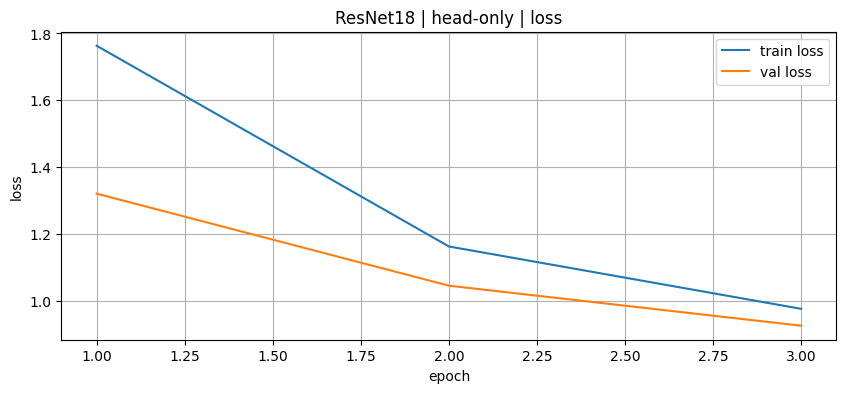

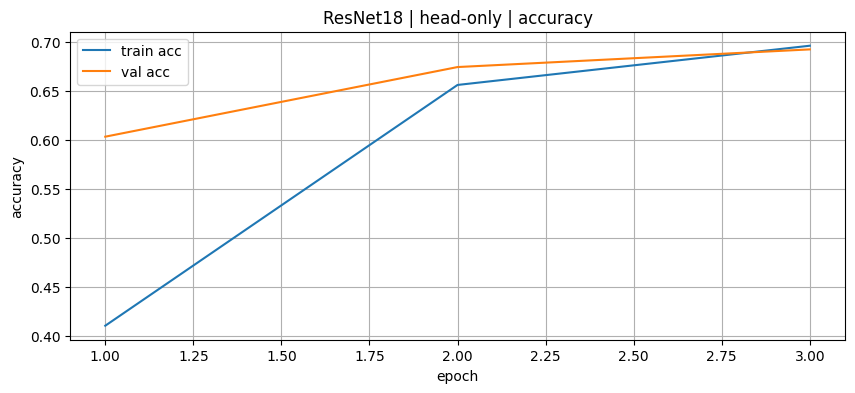

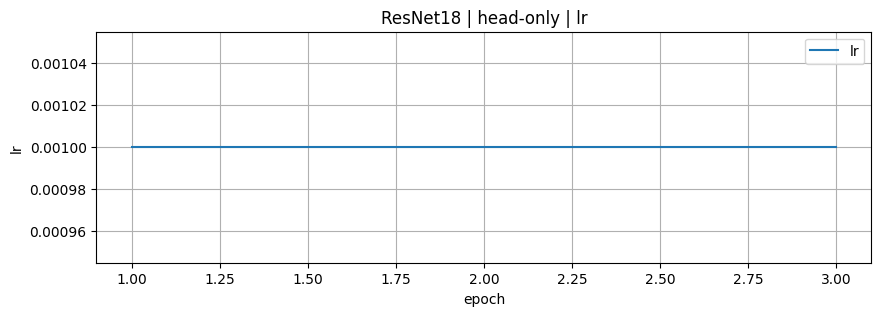

In [20]:

criterion = nn.CrossEntropyLoss()

model_head = build_resnet18(num_classes=10, weights=weights).to(DEVICE)

# freeze всё
set_requires_grad(model_head, False)
# размораживаем только голову
set_requires_grad(model_head.fc, True)

print("Trainable params (head-only):", count_trainable_params(model_head))

optimizer_head = torch.optim.Adam(model_head.fc.parameters(), lr=1e-3)

print("\n" + "=" * 80)
print("Phase 1: head-only training")
hist_head = fit(model_head, train_loader, val_loader, optimizer_head, criterion, epochs=EPOCHS_HEAD, verbose=True)
plot_history(hist_head, title="ResNet18 | head-only")

Trainable params (layer4+fc): 8398858

Phase 2: fine-tuning layer4 + fc
Epoch 01/3 | lr 1.00e-04 | train loss 0.7039, acc 0.757 | val loss 0.5511, acc 0.801 | 174.6s
Epoch 02/3 | lr 1.00e-04 | train loss 0.3997, acc 0.862 | val loss 0.4920, acc 0.819 | 170.4s
Epoch 03/3 | lr 1.00e-04 | train loss 0.2988, acc 0.898 | val loss 0.5061, acc 0.822 | 173.8s


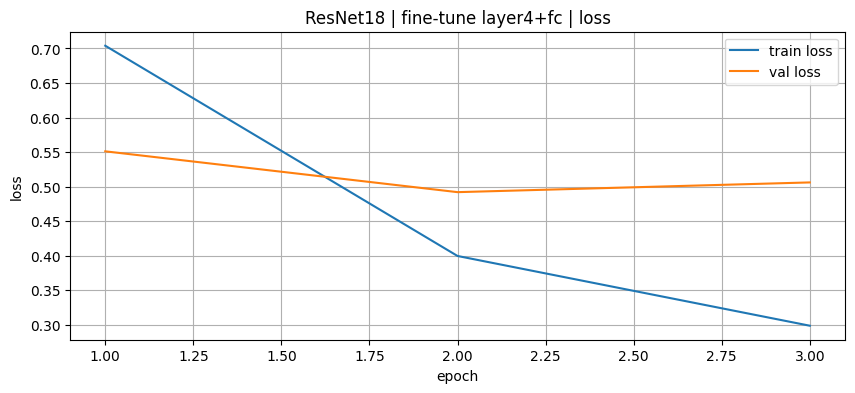

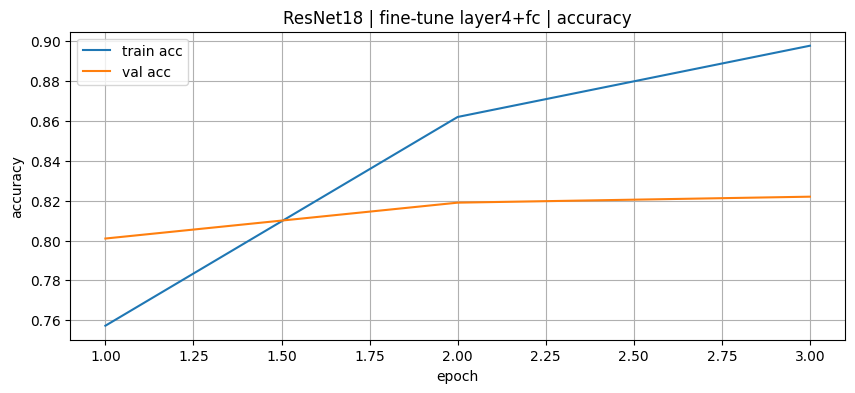

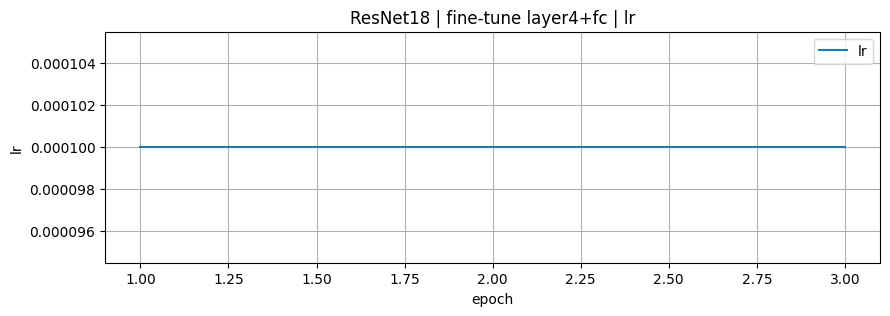

In [21]:
# размораживаем layer4 и fc
set_requires_grad(model_head.layer4, True)
set_requires_grad(model_head.fc, True)

print("Trainable params (layer4+fc):", count_trainable_params(model_head))

# param groups: backbone меньше, head больше
params = [
    {"params": model_head.layer4.parameters(), "lr": 1e-4},
    {"params": model_head.fc.parameters(), "lr": 1e-3},
]

optimizer_ft = torch.optim.Adam(params, weight_decay=1e-4)

print("\n" + "=" * 80)
print("Phase 2: fine-tuning layer4 + fc")
hist_ft = fit(model_head, train_loader, val_loader, optimizer_ft, criterion, epochs=EPOCHS_FT, verbose=True)
plot_history(hist_ft, title="ResNet18 | fine-tune layer4+fc")

In [1]:
import os
import math
import random
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch

print("torch:", torch.__version__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch: 2.10.0+cpu
device: cpu


In [2]:
@dataclass
class RunConfig:
    data_dir: str = "./data"
    fast_mode: bool = False
    n_show: int = 4                 # сколько примеров визуализируем
    score_thr: float = 0.6          # порог по score для предсказаний
    iou_thr: float = 0.5            # порог IoU для TP/FP/FN
    model_name: str = "fasterrcnn_mobilenet_v3_large_fpn"  # быстрее на CPU
    # варианты: "fasterrcnn_resnet50_fpn_v2", "retinanet_resnet50_fpn_v2", ...

cfg = RunConfig()

In [3]:
PENN_URL = "https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip"

def ensure_pennfudan(root: str) -> str:
    '''
    Гарантируем наличие папки root/PennFudanPed.
    Возвращаем путь к PennFudanPed.
    '''
    penn_root = os.path.join(root, "PennFudanPed")
    if os.path.isdir(penn_root):
        return penn_root

    os.makedirs(root, exist_ok=True)

    # Скачивание через torchvision утилиту (если доступно)
    try:
        import torchvision
        from torchvision.datasets.utils import download_and_extract_archive
        print("Downloading PennFudanPed to:", root)
        download_and_extract_archive(PENN_URL, download_root=root, filename="PennFudanPed.zip", remove_finished=False)
        if not os.path.isdir(penn_root):
            raise FileNotFoundError("После распаковки не найдено PennFudanPed/. Проверьте содержимое папки data_dir.")
        return penn_root
    except Exception as e:
        print("Не удалось автоматически скачать датасет.")
        print("Ошибка:", repr(e))
        print("\nВариант вручную:")
        print(f"1) скачайте {PENN_URL}")
        print(f"2) распакуйте так, чтобы было: {penn_root}/PNGImages и {penn_root}/PedMasks")
        raise

penn_root = ensure_pennfudan(cfg.data_dir)

In [4]:
import torch.utils.data

class PennFudanDetDataset(torch.utils.data.Dataset):
    def __init__(self, root: str):
        self.root = root
        self.img_dir = os.path.join(root, "PNGImages")
        self.mask_dir = os.path.join(root, "PedMasks")

        self.imgs = sorted([f for f in os.listdir(self.img_dir) if f.lower().endswith(".png")])
        self.masks = sorted([f for f in os.listdir(self.mask_dir) if f.lower().endswith(".png")])

        if len(self.imgs) == 0 or len(self.imgs) != len(self.masks):
            raise RuntimeError("Похоже, структура PennFudanPed повреждена или не распакована полностью.")

        # преобразуем PIL -> torch.Tensor [0..1]
        try:
            from torchvision.transforms import ToTensor
            self.to_tensor = ToTensor()
        except Exception as e:
            raise RuntimeError("Нужен torchvision для ToTensor().") from e

    def __len__(self) -> int:
        return len(self.imgs)

    def __getitem__(self, idx: int):
        img_path = os.path.join(self.img_dir, self.imgs[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        mask_np = np.array(mask)
        obj_ids = np.unique(mask_np)
        obj_ids = obj_ids[1:]  # 0 = background

        masks = mask_np == obj_ids[:, None, None]   # [N, H, W] boolean

        boxes = []
        for m in masks:
            ys, xs = np.where(m)
            xmin, xmax = xs.min(), xs.max()
            ymin, ymax = ys.min(), ys.max()
            boxes.append([xmin, ymin, xmax, ymax])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.ones((boxes.shape[0],), dtype=torch.int64)  # в датасете только "person"
        image_id = torch.tensor([idx], dtype=torch.int64)
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        iscrowd = torch.zeros((boxes.shape[0],), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd,
        }

        img_t = self.to_tensor(img)
        return img_t, target

def collate_fn(batch):
    return tuple(zip(*batch))

dataset = PennFudanDetDataset(penn_root)
len(dataset), dataset[0][0].shape, dataset[0][1].keys()

(170,
 torch.Size([3, 536, 559]),
 dict_keys(['boxes', 'labels', 'image_id', 'area', 'iscrowd']))

In [5]:
def get_detection_model(name: str):
    import torchvision
    from torchvision.models.detection import (
        fasterrcnn_resnet50_fpn_v2,
        fasterrcnn_mobilenet_v3_large_fpn,
        retinanet_resnet50_fpn_v2,
        FasterRCNN_ResNet50_FPN_V2_Weights,
        FasterRCNN_MobileNet_V3_Large_FPN_Weights,
        RetinaNet_ResNet50_FPN_V2_Weights,
    )

    name = name.strip()

    if name == "fasterrcnn_resnet50_fpn_v2":
        weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
        model = fasterrcnn_resnet50_fpn_v2(weights=weights)
    elif name == "retinanet_resnet50_fpn_v2":
        weights = RetinaNet_ResNet50_FPN_V2_Weights.DEFAULT
        model = retinanet_resnet50_fpn_v2(weights=weights)
    elif name == "fasterrcnn_mobilenet_v3_large_fpn":
        weights = FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT
        model = fasterrcnn_mobilenet_v3_large_fpn(weights=weights)
    else:
        raise ValueError(f"Unknown model_name: {name}")

    categories = weights.meta.get("categories", None)
    person_label = None
    if categories and "person" in categories:
        person_label = categories.index("person")  # у COCO обычно 1

    model.eval()
    return model, weights, categories, person_label

model, weights, categories, person_label = get_detection_model(cfg.model_name)
model.to(DEVICE)
print("model:", cfg.model_name)
print("person_label:", person_label)

model: fasterrcnn_mobilenet_v3_large_fpn
person_label: 1


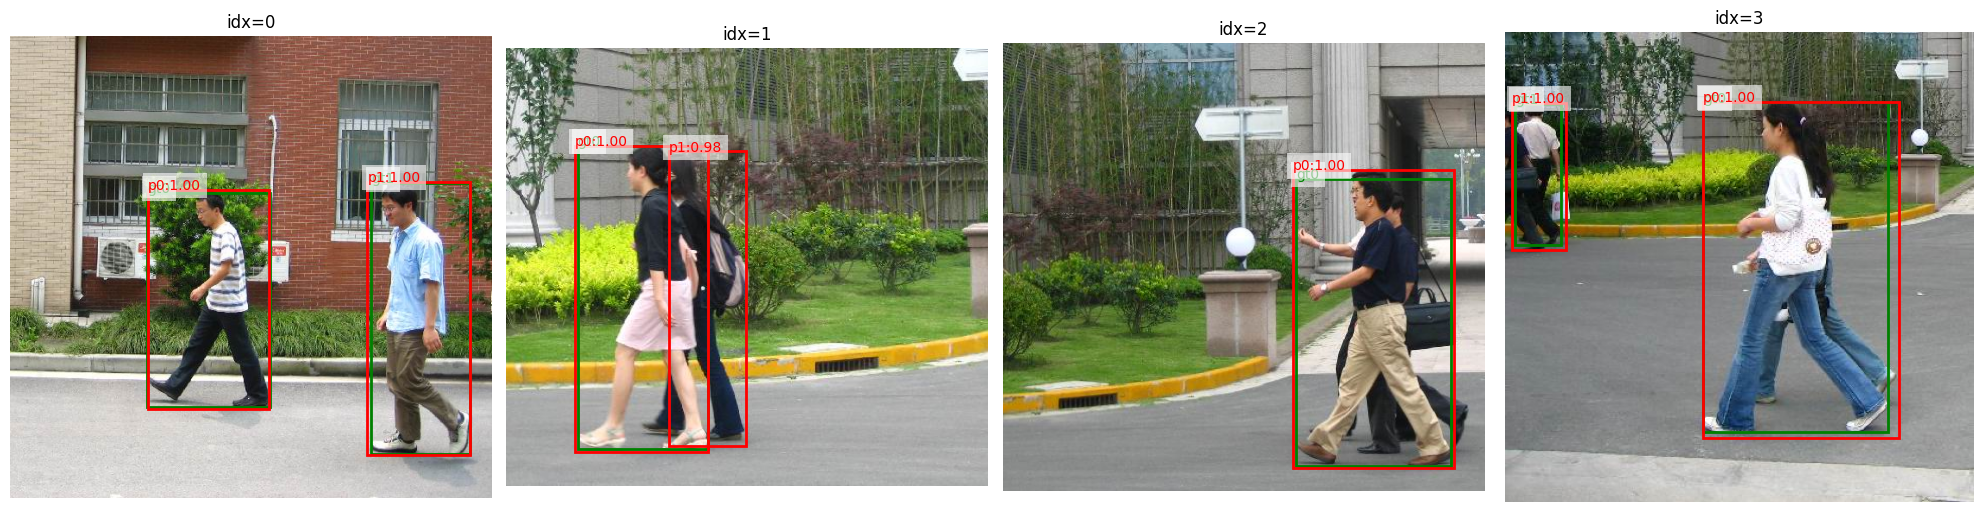

In [6]:
def draw_boxes(ax, boxes, color="r", linewidth=2, text=None):
    import matplotlib.patches as patches
    for i, b in enumerate(boxes):
        x1, y1, x2, y2 = [float(v) for v in b]
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=linewidth, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        if text is not None:
            ax.text(x1, y1, text(i), color=color, fontsize=10,
                    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))

@torch.no_grad()
def predict_one(img_t: torch.Tensor) -> Dict[str, torch.Tensor]:
    out = model([img_t.to(DEVICE)])[0]
    out = {k: v.detach().cpu() for k, v in out.items()}
    return out

def filter_preds(pred: Dict[str, torch.Tensor], score_thr: float, person_label: Optional[int]) -> Dict[str, torch.Tensor]:
    keep = pred["scores"] >= score_thr
    if person_label is not None and "labels" in pred:
        keep = keep & (pred["labels"] == int(person_label))
    return {k: v[keep] for k, v in pred.items()}

# Покажем несколько примеров
n = min(cfg.n_show, len(dataset))
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1:
    axes = [axes]

for i in range(n):
    img_t, target = dataset[i]
    pred = predict_one(img_t)
    pred_f = filter_preds(pred, cfg.score_thr, person_label)

    img_np = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    ax = axes[i]
    ax.imshow(img_np)
    ax.set_title(f"idx={i}")
    ax.axis("off")

    # GT - зелёный, Pred - красный
    draw_boxes(ax, target["boxes"], color="g", linewidth=2, text=lambda j: f"gt{j}")
    draw_boxes(ax, pred_f["boxes"], color="r", linewidth=2, text=lambda j: f"p{j}:{pred_f['scores'][j]:.2f}")

plt.tight_layout()
plt.show()

In [7]:
def box_iou_matrix(boxes1: torch.Tensor, boxes2: torch.Tensor) -> torch.Tensor:
    '''
    boxes: [N,4] and [M,4] in (x1,y1,x2,y2), returns [N,M]
    '''
    if boxes1.numel() == 0 or boxes2.numel() == 0:
        return torch.zeros((boxes1.shape[0], boxes2.shape[0]), dtype=torch.float32)

    x1 = torch.max(boxes1[:, None, 0], boxes2[None, :, 0])
    y1 = torch.max(boxes1[:, None, 1], boxes2[None, :, 1])
    x2 = torch.min(boxes1[:, None, 2], boxes2[None, :, 2])
    y2 = torch.min(boxes1[:, None, 3], boxes2[None, :, 3])

    inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)

    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0)
    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0)

    union = area1[:, None] + area2[None, :] - inter + 1e-9
    return inter / union

def match_greedy(pred_boxes: torch.Tensor, pred_scores: torch.Tensor, gt_boxes: torch.Tensor, iou_thr: float) -> Tuple[int, int, int, float]:
    '''
    Жадный матчинг: идём по pred по убыванию score, матчим к лучшему ещё не занятому GT.
    Возвращаем TP, FP, FN и средний IoU по матчам.
    '''
    if pred_boxes.numel() == 0:
        tp, fp, fn = 0, 0, int(gt_boxes.shape[0])
        return tp, fp, fn, float("nan")

    order = torch.argsort(pred_scores, descending=True)
    pred_boxes = pred_boxes[order]
    pred_scores = pred_scores[order]

    iou = box_iou_matrix(pred_boxes, gt_boxes)  # [P,G]
    gt_used = torch.zeros((gt_boxes.shape[0],), dtype=torch.bool)

    tp = 0
    fp = 0
    ious = []

    for p in range(pred_boxes.shape[0]):
        if gt_boxes.shape[0] == 0:
            fp += 1
            continue
        best_iou, best_j = torch.max(iou[p], dim=0)
        best_iou = float(best_iou.item())
        best_j = int(best_j.item())

        if best_iou >= iou_thr and not gt_used[best_j]:
            tp += 1
            gt_used[best_j] = True
            ious.append(best_iou)
        else:
            fp += 1

    fn = int((~gt_used).sum().item())
    mean_iou = float(np.mean(ious)) if len(ious) else float("nan")
    return tp, fp, fn, mean_iou

def evaluate_subset(indices: List[int]) -> Dict[str, float]:
    tps = fps = fns = 0
    ious = []
    for idx in indices:
        img_t, target = dataset[idx]
        pred = predict_one(img_t)
        pred_f = filter_preds(pred, cfg.score_thr, person_label)

        tp, fp, fn, miou = match_greedy(pred_f["boxes"], pred_f["scores"], target["boxes"], cfg.iou_thr)
        tps += tp
        fps += fp
        fns += fn
        if math.isfinite(miou):
            ious.append(miou)

    precision = tps / (tps + fps + 1e-9)
    recall = tps / (tps + fns + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    mean_iou = float(np.mean(ious)) if len(ious) else float("nan")

    return {
        "TP": float(tps),
        "FP": float(fps),
        "FN": float(fns),
        "precision@IoU": precision,
        "recall@IoU": recall,
        "F1@IoU": f1,
        "mean_IoU_matched": mean_iou,
    }

# Оцениваем небольшое подмножество (быстро), либо больше (если fast_mode=False)
if cfg.fast_mode:
    eval_indices = list(range(min(20, len(dataset))))
else:
    eval_indices = list(range(len(dataset)))

metrics = evaluate_subset(eval_indices)
metrics

{'TP': 418.0,
 'FP': 253.0,
 'FN': 5.0,
 'precision@IoU': 0.6229508196712028,
 'recall@IoU': 0.9881796690283967,
 'F1@IoU': 0.7641681896522682,
 'mean_IoU_matched': 0.9051248345530334}

In [8]:
from pathlib import Path


artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)
model_path = artifacts_dir / "best_model.pt"
torch.save(model.state_dict(), model_path)
print(f"✓ Saved best model to {model_path}")

✓ Saved best model to artifacts\best_model.pt
